<a href="https://colab.research.google.com/github/dakshking0218/Customer-Churn-Prediction-/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telecom Customer Churn Prediction: Feature Optimization & Imbalance Handling
**Objective:** Predict subscription churn in a highly imbalanced dataset using binary classification models.
**Engineering Focus:** This pipeline emphasizes strict prevention of data leakage through proper train/test isolation, mitigates multicollinearity using baseline one-hot encoding, and handles class imbalance using weighted algorithmic penalties. It leverages a Random Forest architecture for dimensionality reduction before passing the optimized feature set into an interpretable Logistic Regression model.

**Python (Imports & Configuration)**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Styling
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## 1. Data Ingestion & Sanitization
Financial data often contains hidden nulls (e.g., new customers with blank 'TotalCharges'). We coerce these to `NaN` and drop them (as they account for <0.2% of the dataset). We also isolate our target variable, converting 'Churn' to a strict 1/0 binary integer.

In [ ]:
# Load Data
df = pd.read_csv('/content/Telco-Customer-Churn.csv')

# Drop ID as it holds no predictive mathematical value
df.drop('customerID', axis=1, inplace=True)

# Coerce blank strings in TotalCharges to NaN, then drop those 11 rows
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# Isolate target variable and convert to 1 (Churn) and 0 (Stay)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"Cleaned Dataset Shape: {df.shape}")
print(f"Target Class Imbalance:\\n{df['Churn'].value_counts(normalize=True) * 100}")

Cleaned Dataset Shape: (7032, 20)
Target Class Imbalance:\nChurn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


## 2. Encoding & Train/Test Isolation (Preventing Data Leakage)
To prevent the **Dummy Variable Trap**, we apply `drop_first=True` during one-hot encoding.
**CRITICAL:** We must split our data into Training and Testing sets *before* applying any scaling. If we scale the entire dataset first, statistical information from the test set "leaks" into the training phase, artificially inflating the model's performance.

In [ ]:
# 1. One-Hot Encode Categorical Variables (Mitigating Multicollinearity)
categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

# 2. Define Features (X) and Target (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# 3. Train-Test Split (80/20) with Stratification to maintain the 73/27 imbalance ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")

Training Features Shape: (5625, 30)
Testing Features Shape: (1407, 30)


## 3. Standard Scaling & Dimensionality Reduction
We fit the `StandardScaler` strictly on the training data, applying the transformation to both sets. Then, we utilize a **Random Forest Classifier** to evaluate feature importance. Using `SelectFromModel`, we discard mathematical noise, isolating only the highest-impact features to feed into our final predictive model.

In [ ]:
# 1. Scale Continuous Numerical Variables
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()

# Fit ONLY on training data, transform both
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# 2. Feature Selection using Random Forest
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train, y_train)

# Select features that have an importance greater than the median
selector = SelectFromModel(rf_selector, threshold='median', prefit=True)

X_train_optimized = selector.transform(X_train)
X_test_optimized = selector.transform(X_test)

# Capture the names of the surviving features
selected_feature_indices = selector.get_support(indices=True)
selected_features = X_train.columns[selected_feature_indices]

print(f"Original feature count: {X_train.shape[1]}")
print(f"Optimized feature count: {X_train_optimized.shape[1]}")

Original feature count: 30
Optimized feature count: 15


## 4. Model Training & Evaluation
We deploy a **Logistic Regression** model on the optimized feature set. Because our data is imbalanced (73% stay, 27% leave), accuracy is a deceptive metric. Instead, we pass `class_weight='balanced'` into our model. This mathematically penalizes the algorithm more heavily for missing a churning customer, sacrificing a small amount of overall accuracy to vastly improve **Recall** (the business metric that actually matters for retention).

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.69      0.78      1033
           1       0.48      0.80      0.60       374

    accuracy                           0.72      1407
   macro avg       0.69      0.74      0.69      1407
weighted avg       0.79      0.72      0.74      1407

ROC AUC Score: 0.8321\n


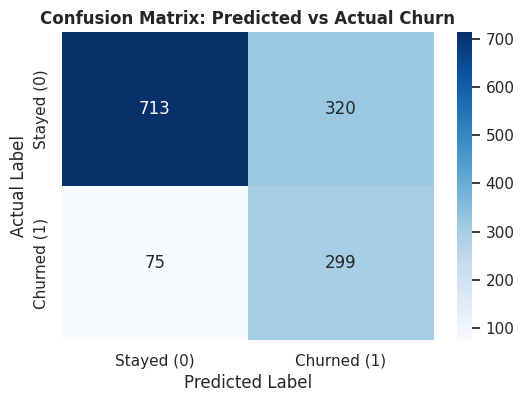

In [ ]:
# Initialize Logistic Regression with Balanced Class Weights
log_reg = LogisticRegression(class_weight='balanced', random_state=42)
log_reg.fit(X_train_optimized, y_train)

# Generate Predictions
y_pred = log_reg.predict(X_test_optimized)
y_prob = log_reg.predict_proba(X_test_optimized)[:, 1] # Probabilities for ROC AUC

# Print Advanced Evaluation Metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}\\n")

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed (0)', 'Churned (1)'],
            yticklabels=['Stayed (0)', 'Churned (1)'])
plt.title('Confusion Matrix: Predicted vs Actual Churn', fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

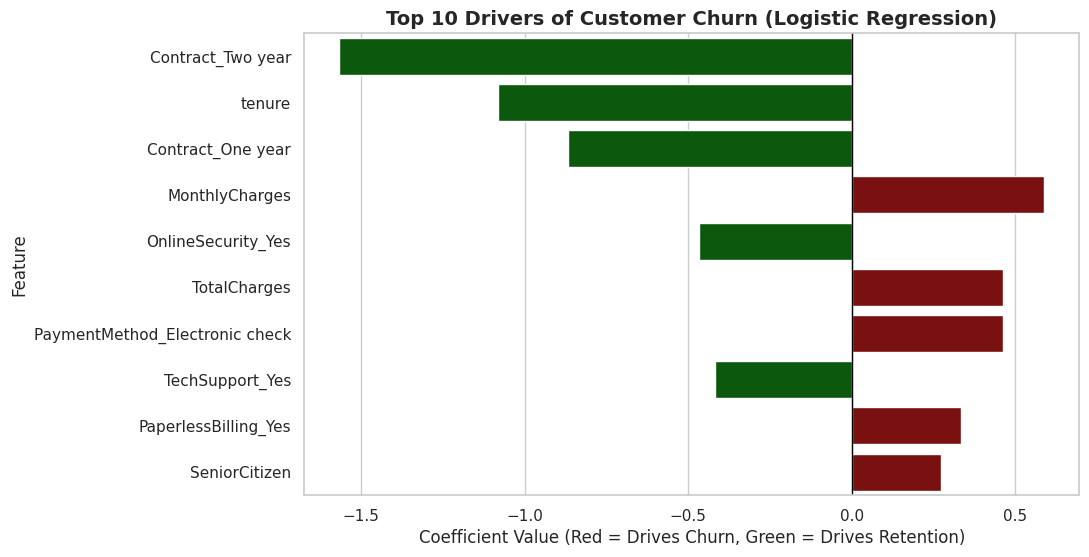

In [ ]:
# Extract Coefficients from Logistic Regression
coefficients = log_reg.coef_[0]

# Map back to the selected feature names
feature_importance = pd.DataFrame({
    'Feature': selected_features,
    'Impact (Coefficient)': coefficients
})

# Sort by absolute impact
feature_importance['Absolute Impact'] = feature_importance['Impact (Coefficient)'].abs()
feature_importance = feature_importance.sort_values(by='Absolute Impact', ascending=False)

# Isolate the top 10 features
top_10 = feature_importance.head(10)

# Create a standard Python list for the colors to prevent the ValueError
colors = ['darkred' if x > 0 else 'darkgreen' for x in top_10['Impact (Coefficient)']]

# Plotting the top 10 churn drivers
plt.figure(figsize=(10, 6))

# Added hue='Feature' and legend=False for modern Seaborn compatibility
sns.barplot(x='Impact (Coefficient)', y='Feature', data=top_10,
            palette=colors, hue='Feature', legend=False)

plt.title('Top 10 Drivers of Customer Churn (Logistic Regression)', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value (Red = Drives Churn, Green = Drives Retention)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.axvline(0, color='black', linewidth=1)
plt.show()
